In [11]:

import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy
import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats
import importlib
import multi_exp_log
sys.path.append('..')
sys.path.append('comparisons')
import plot_settings

import GP
import Flat_model_nets
import protocol

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(multi_exp_log)
    importlib.reload(GP)
    importlib.reload(Flat_model_nets)
    importlib.reload(protocol)

import_reload()
GP_FIT = GP.GP_process()

import warnings
warnings.filterwarnings("ignore", message=".*__array_wrap__.*")

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/5_Multi/GP.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


# Importing data

In [12]:
DT = 1
Q0 = 17921.57581 
MODE = (True, 'func')  # (constraints, R0_mode)
MODEL_NAME = f'{MODE[0]}_C_{MODE[1]}'
SAVEPLOTS = True
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')
print(f'NOW RUNNING MODEL: {MODEL_NAME}')

NOW RUNNING MODEL: True_C_func


In [13]:
def read_raw_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        delim_whitespace=True,
        comment="%",
        header=None
    )
    df.columns = ['u_par','C','t','E_cell (V)','I_cell (A)','Rx_cell (N)','u_cell (m)','E_ocv_cell (V)','soc_cell (1)']
    return df

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    # cols = u_par,C,t,V,I,F,u,Ue,eta,trajectory,dV,dF,soc
    #df.columns = ['u_par','C','t','V','I','F','u','Ue','eta','trajectory','dV','dF','soc']
    # Sort by time within each batch
    return df

data = read_data('2_merged_data')
u_par_u = (data['u_par'] / data['u']).values[0]

To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [14]:
def get_traj_data(trajectory, col,df = data):
    """
    Extract data for a specific trajectory.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a 'trajectory' column.
    trajectory : int
        The trajectory number to extract.

    Returns
    -------
    pd.DataFrame
        Dataframe containing only the data for the specified trajectory.
    """
    return df[col][df['trajectory'] == trajectory].reset_index(drop=True)

# Plotting data

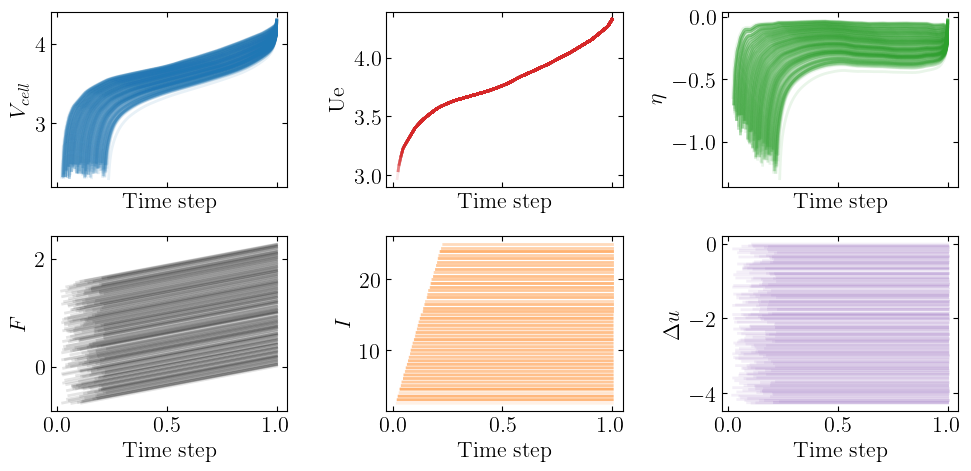

In [15]:


f, ax = plt.subplots(2, 3, figsize=(10, 5),sharex=True)
for plot_idx in range(data['trajectory'].nunique()):
    ax[0,0].plot(data['soc'][data['trajectory'] == plot_idx],data['V'][data['trajectory'] == plot_idx], '-', color = colors[0], lw = 2,alpha = 0.1)
    ax[0,0].set_xlabel('Time step')
    ax[0,0].set_ylabel('$V_{cell}$')
    ax[0,1].plot(data['soc'][data['trajectory'] == plot_idx],data['Ue'][data['trajectory'] == plot_idx], '-', color = colors[1], lw = 2,alpha = 0.1)
    ax[0,1].set_xlabel('Time step')
    ax[0,1].set_ylabel('Ue')
    ax[0,2].plot(data['soc'][data['trajectory'] == plot_idx],data['eta'][data['trajectory'] == plot_idx], '-', color = colors[2], lw = 2,alpha = 0.1)
    ax[0,2].set_xlabel('Time step')
    ax[0,2].set_ylabel(r'$\eta$')
    ax[1,0].plot(data['soc'][data['trajectory'] == plot_idx],data['F'][data['trajectory'] == plot_idx], lw = 2,color = colors[3],alpha = 0.1)
    ax[1,0].set_xlabel('Time step')
    ax[1,0].set_ylabel(r'$F$')
    ax[1,1].plot(data['soc'][data['trajectory'] == plot_idx],data['I'][data['trajectory'] == plot_idx], lw = 2,color = colors[4],alpha = 0.1)
    ax[1,1].set_xlabel('Time step')
    ax[1,1].set_ylabel(r'$I$')
    ax[1,2].plot(data['soc'][data['trajectory'] == plot_idx],data['u'][data['trajectory'] == plot_idx], lw = 2,color = colors[5],alpha = 0.1)
    ax[1,2].set_xlabel('Time step')
    ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()

53.164 GN/mm
0.5316441632537718


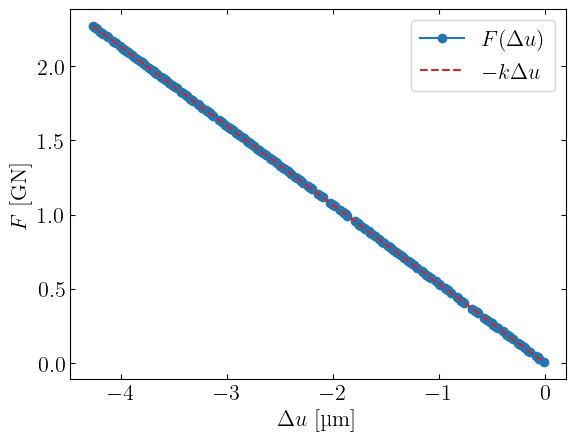

In [16]:
traj = 0
#plt.plot(data['u'][data['trajectory'] == traj], data['F'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u')['F']


first_F = data.groupby('u')['F'].first()
k = abs(first_F / (data.groupby('u')['u'].first()))
plt.plot(data.groupby('u')['u'].first(), first_F, 'o-', color = colors[0], label = r'$F(\Delta u)$')
plt.plot(data.groupby('u')['u'].first(), -k * data.groupby('u')['u'].first(), '--', color = colors[1], label = r'$-k\Delta u$')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$F$ [GN]')
plt.legend()
print(f'{100 * k.values[0]:.3f} GN/mm')
print(k.values[0])


Text(0, 0.5, '$F$ [MN]')

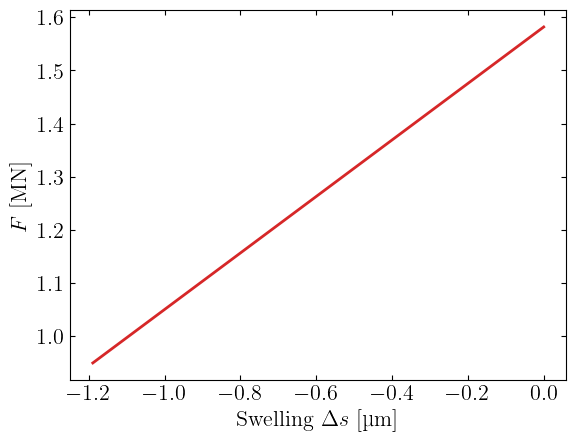

In [17]:
traj = 1

ds = data['F'][data['trajectory'] == traj] / k.values[0] + data['u'][data['trajectory'] == traj] 

plt.plot(ds,data['F'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel(r'Swelling $\Delta s$ [µm]')
plt.ylabel(r'$F$ [MN]')

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

In [18]:
N_trajs = len(data['trajectory'].unique())


X = data[['I','u','soc','Ue','trajectory']].values
y = data[['V','F','trajectory']].values

In [19]:
N_trajs = len(data['trajectory'].unique())

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 1 - train_ratio - val_ratio

split_train = (data['trajectory']<=int(N_trajs *train_ratio)).sum()
print(f'split train: {split_train}')
def _split_flat(arr,split = split_train):

    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test_val = _split_flat(x_tensor); y_train, y_test_val = _split_flat(y_tensor)

split_val = (data['trajectory']<=int(N_trajs * (train_ratio+val_ratio))).sum() - split_train 
print(f'split val: {split_val}')
x_val, x_test = _split_flat(x_test_val, split=split_val); y_val, y_test = _split_flat(y_test_val, split=split_val)

print(f'Number of trajectories in train: {int(N_trajs * train_ratio)} number trajectories in val: {int(N_trajs * val_ratio)} number trajectories in test: {int(N_trajs * test_ratio)}out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-val shape: {x_val.shape}\ty-val shape: {y_val.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')


split train: 286531
split val: 70054
Number of trajectories in train: 173 number trajectories in val: 37 number trajectories in test: 37out of 248
X shape torch.Size([415557, 5])	y shape torch.Size([415557, 3])
X-train shape: torch.Size([286531, 5])	y-train shape: torch.Size([286531, 3])
X-val shape: torch.Size([70054, 5])	y-val shape: torch.Size([70054, 3])
X-test shape: torch.Size([58972, 5])	y-test shape: torch.Size([58972, 3])


# Set NN params

In [42]:
def get_NN_params():
    epochs = 200
    lr = 1e-3
    threshold_rmse = 0.01
    return epochs, lr, threshold_rmse

def RMSE(pred, target):
    return torch.sqrt(torch.mean((pred - target)**2) + 1e-8)

def get_model():
    model = Flat_model_nets.U1Net(input_size=4, hidden_size=64)
    return model

def get_pulses(t = False):
    data_pulse = pd.read_csv('Multi_data/pulse_data1.txt')
    x = data_pulse[['I','u','soc','Ue', 'trajectory']].values
    y = data_pulse[['V','F','trajectory']].values
    x_tensor = torch.tensor(x, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    if t:
        t = data_pulse[['t','trajectory']].values
        return x_tensor, y_tensor, t
    else:
        return x_tensor, y_tensor

def get_data(d_type, x_train = x_train, y_train = y_train, x_test_val = x_test_val, y_test_val = y_test_val, t = False):
    if d_type == 'pulse':
        return get_pulses(t = t)
    elif d_type == 'train':
        return x_train, y_train
    elif d_type == 'test_val':
        return x_test_val, y_test_val
    else:
        raise ValueError(f'Invalid data type: {d_type}')

In [21]:
def workout(mode, 
            x_train=x_train, y_train=y_train, 
            x_val=x_val, y_val=y_val, 
            N_trajs_train = int(N_trajs * train_ratio), 
            N_trajs_val = int(N_trajs * val_ratio)):
    

    history = {
        "loss": [], "V_loss": [], "F_loss": [],
        "val_loss": [], "val_V_loss": [], "val_F_loss": [],
        "time per ep": []
    }

    epochs, lr, threshold_rmse = get_NN_params()
    const, R0 = mode

    model = get_model()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    tot_time = 0.
    MAX_TIME_min = 15

    for ep in range(epochs):
        start_t = time.perf_counter()    
        
        model.train()
        ep_loss = 0.0
        ep_V_loss = 0.0
        ep_F_loss = 0.0

        for traj in range(N_trajs_train):

            x_traj = x_train[x_train[:, -1] == traj]
            y_traj = y_train[y_train[:, -1] == traj]

            model_input = x_traj[:, :-1]
            model_target = y_traj[:, :-1]
            #print(model_input.shape, model_target.shape )

            y_pred = Flat_model_nets.next_step(
                model, model_input, constraints=const, R0_mode=R0
            )

            if torch.isnan(y_pred).any():
                print("NaN in y_pred")
                print("x:", x_traj[:5])
                break

            if torch.isinf(y_pred).any():
                print("Inf in y_pred")
                break
            V_loss =RMSE(y_pred[:, 0], model_target[:, 0])
            F_loss = RMSE(y_pred[:, 1], model_target[:, 1])
            loss = V_loss + F_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            ep_loss += loss.item()
            ep_V_loss += V_loss.item()
            ep_F_loss += F_loss.item()

        ep_loss /= N_trajs
        ep_V_loss /= N_trajs
        ep_F_loss /= N_trajs


        model.eval()
        val_loss = 0.0
        val_V_loss = 0.0
        val_F_loss = 0.0

        with torch.no_grad():
            for traj in range(N_trajs_train+1, N_trajs_val + N_trajs_train):

                x_traj = x_val[x_val[:, -1] == traj]
                y_traj = y_val[y_val[:, -1] == traj]

                model_input = x_traj[:, :-1]
                model_target = y_traj[:, :-1]

                y_pred = Flat_model_nets.next_step(
                    model, model_input, constraints=const, R0_mode=R0
                )
                if x_traj.shape[0] == 0:
                    print(f"Empty val traj: {traj}")
                    break
                if torch.isnan(y_pred).any():
                    print('VAL\n')
                    print("NaN in y_pred")
                    print("x:", x_traj[:5])
                    break

                if torch.isinf(y_pred).any():
                    print('VAL\n')
                    print("Inf in y_pred")
                    break
                if torch.isnan(model_target).any():
                    print("NaN in target!")
                    break

                if torch.isinf(model_target).any():
                    print("Inf in target!")
                    break

                V_l = RMSE(y_pred[:, 0], model_target[:, 0])
                F_l = RMSE(y_pred[:, 1], model_target[:, 1])
                l = V_l + F_l

                val_loss += l.item()
                val_V_loss += V_l.item()
                val_F_loss += F_l.item()

        val_loss /= N_trajs
        val_V_loss /= N_trajs
        val_F_loss /= N_trajs


        history["val_loss"].append(val_loss)
        history["val_V_loss"].append(val_V_loss)
        history["val_F_loss"].append(val_F_loss)

        history["loss"].append(ep_loss)
        history["V_loss"].append(ep_V_loss)
        history["F_loss"].append(ep_F_loss)

        end_t = time.perf_counter()
        history["time per ep"].append(end_t - start_t)   
        tot_time += end_t - start_t

        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > MAX_TIME_min * 60:
            print(f"Early stopping: Total training time exceeded {MAX_TIME_min} minutes.")
            break

        print(
            f'Epoch {ep+1}/{epochs} | '
            f'loss {ep_loss:.2e} | val_loss {val_loss:.2e} | '
            f'V {ep_V_loss:.2e}/{val_V_loss:.2e} | '
            f'F {ep_F_loss:.2e}/{val_F_loss:.2e} | '
            f'time {end_t - start_t:.2f}s'
        )

    return history, model

In [22]:

def plot_history(history,save=SAVEPLOTS, model_name = MODEL_NAME):
    fig, ax = plt.subplot_mosaic(
        [
            ["loss", "combined"],
            ["V_loss", "combined"],
            ["F_loss", "combined"]
        ],
        figsize=(12, 5),
        sharex=True
    )

    # Individual plots
    ax["loss"].semilogy(history["loss"], label="Train loss", color=colors[0])
    ax['loss'].semilogy(history["val_loss"], label="Val loss", color=colors[0], ls='--',alpha = 0.6)
    ax["V_loss"].semilogy(history["V_loss"], label=r"Train $R$ loss", color=colors[1])
    ax['V_loss'].semilogy(history["val_V_loss"], label=r"Val $R$ loss", color=colors[1], ls='--',alpha = 0.6)
    ax["F_loss"].semilogy(history["F_loss"], label=r"Train $F$ loss", color=colors[2])
    ax['F_loss'].semilogy(history["val_F_loss"], label=r"Val $F$ loss", color=colors[2], ls='--',alpha = 0.6)

    # Combined plot (all together)
    ax["combined"].semilogy(history["loss"], label="Loss", color=colors[0])
    ax['combined'].semilogy(history["val_loss"], label="Val loss", color=colors[0], ls='--',alpha = 0.6)
    ax["combined"].semilogy(history["V_loss"], label=r"$R$ loss", color=colors[1])
    ax['combined'].semilogy(history["val_V_loss"], label=r"Val $R$ loss", color=colors[1], ls='--',alpha = 0.6)
    ax["combined"].semilogy(history["F_loss"], label=r"$F$ loss", color=colors[2])
    ax['combined'].semilogy(history["val_F_loss"], label=r"Val $F$ loss", color=colors[2], ls='--',alpha = 0.6)


    # Labels and styling
    ax["F_loss"].set_xlabel("epoch")
    ax["combined"].set_xlabel("epoch")

    for key in ["loss", "V_loss", "F_loss", "combined"]:
        ax[key].set_ylabel("RMSE")
        ax[key].legend()
        ax[key].grid(True, which="both", ls="--", lw=0.5)

    plt.tight_layout()
    if save:
       plt.savefig(f'comparisons/figs/tr_curve_{model_name}.pdf')
    print(np.mean(history['loss'][-5:]))
    plt.show()

#plot_history(history)

In [51]:
def evaluate(model, x_test, y_test, ret_loss = False,mode = MODE):
    const, R0 = mode
    model.eval()
    with torch.no_grad():
        y_pred = Flat_model_nets.next_step(
            model, x_test, constraints=const, R0_mode=R0
        )

    if ret_loss:
        Vloss = RMSE(y_pred[:, 0], y_test[:, 0]) 
        Floss = RMSE(y_pred[:, 1], y_test[:, 1])
        return y_pred.detach().numpy(), Vloss, Floss
    else:
        return y_pred.detach().numpy()

def plot_predictions(traj_eval,model, d_type = 'test_val', k = k.values[0], save = False, model_name = MODEL_NAME, mode = MODE, t = False):
    
    if t:
        X, Y,T = get_data(d_type,t= t)
    else:
        X, Y = get_data(d_type)
    
    traj_eval = traj_eval + X[:,-1].min().item()  # Adjust for trajectory indexing
    #print(f'Plotting trajectory {traj_eval} from {d_type} set')
    #print(f'x shape: {x.shape}\ty shape: {y.shape}')
    #print(f'Unique trajectories in x: {torch.unique(x[:,-1])}\nUnique trajectories in y: {torch.unique(y[:,-1])}')
    x_i = X[X[:,-1] == traj_eval][:,:-1]; y_i = Y[Y[:,-1] == traj_eval][:,:-1]
    
    y_pred = evaluate(model, x_i,y_i, mode=mode)
    x = x_i.numpy()
    y = y_i.numpy()
    f, ax = plt.subplots(2, 2, figsize=(10, 8))
    soc = x[:,2]
    if t:
        soc = T[T[:,-1] == traj_eval][:,0]
    Ue = x[:,3]
    u = x[:,1]
    V = y[:,0]; V_pred = y_pred[:,0]
    F = y[:,1]; F_pred = y_pred[:,1]
    eta = Ue - V; 
    eta_pred = Ue - y_pred[:,0]
    #plt.plot(x_test[:,0].numpy()* R0.detach().numpy(), label='Predicted $R_0$')
    ax[0,0].plot(soc,eta, label=r'True $\eta$',color = colors[1],ls = '--',lw = 2)
    ax[0,0].plot(soc,eta_pred, label=r'Predicted $\eta$',color = colors[0],lw = 2)
    #ax[0,0].set_xlim(0.9,1.01)
    #ax[0,0].set_ylim(0.1,.5)

    ax[0,1].plot(soc,V, label=r'True $V$', color = colors[1],ls = '--',lw = 2.5)
    ax[0,1].plot(soc,V_pred, label=r'Predicted $V$', color = colors[0],lw = 2)

    ax[1,0].plot(soc,F, label=r'True $F$', color = colors[1],ls = '--',lw = 2)
    ax[1,0].plot(soc,F_pred, label=r'Predicted $F$', color = colors[0],lw = 2)    

    ax[1,1].plot(soc,F - k*u, label=r'True $F_s$', color = colors[1], ls = '--',lw = 2)
    ax[1,1].plot(soc,F_pred - k * u, label=r'Pred $F_s$', color = colors[0],lw = 2)

    for a in ax.flat:
        a.legend()
        if t:
            
            a.set_xlabel('Time [s]')
        else:
            a.set_xlabel('State of Charge')
            a.invert_xaxis()
    ax[0,0].set_ylabel(r'Overpotential $\eta$ [V]')
    ax[0,1].set_ylabel(r'$V$ [V]')
    ax[1,0].set_ylabel(r'$F$ [GN]')
    ax[1,1].set_ylabel(r'Swelling force $F_s$ [GN]')
    plt.tight_layout() 
    if save:
        plt.savefig(f'comparisons/figs/pred_traj_{model_name}.pdf')
    plt.show()

In [24]:
def evaluate_metrics(model, x, y, noise = False):
    model.eval()
    steps = 11
    rmse = np.zeros((torch.unique(x[:, -1]).numel(),2))
    rmse_noise = np.zeros((steps,torch.unique(x[:, -1]).numel(),2))
    j = 0
    I_ = []; u_ = []; noise_level = []
    if noise:
            for i in trange(steps):
                for j,traj in enumerate(x[:,-1].unique()):

                    x_traj = x[x[:,-1] == traj][:,:-1]
                    y_traj = y[y[:,-1] == traj][:,:-1]
                    I_.append(x_traj[3,0])
                    u_.append(x_traj[3,1])
                    n_lvl = 0.02 * i
                    noise_level.append(n_lvl)

                    I_noise,u_noise = protocol.gen_noise(x_traj[:,0], x_traj[:,1], noise_lvl = n_lvl)
                    #soc_noise = torch.randn_like(x_traj[:,2]) * 0.01 * i * x_traj[:,2].abs()

                    x_traj_noisy = x_traj.clone()
                    x_traj_noisy[:,0] += I_noise
                    x_traj_noisy[:,1] += u_noise
                    x_traj_noisy[:,2] += I_noise / Q0
                    x_traj_noisy[:,2] = torch.clamp(x_traj_noisy[:,2], 0, 1)  # Ensure SOC stays in [0, 1]
                    x_traj_noisy[:,3] = torch.tensor(GP.soc_to_Ue(x_traj_noisy[:,2],GP_FIT))
                    with torch.no_grad():
    
                        y_pred, Vloss, Floss = evaluate(model, x_traj_noisy, y_traj, ret_loss=True)
                    y_true = y_traj.numpy()
    
                    rmse_noise[i,j,0] = Vloss.item()
                    rmse_noise[i,j,1] = Floss.item()
                j += 1
            return rmse_noise, np.asarray(I_), np.asarray(u_), np.asarray(noise_level)
    else:
        for j,traj in enumerate(x[:,-1].unique()):
            x_traj = x[x[:,-1] == traj][:,:-1]
            y_traj = y[y[:,-1] == traj][:,:-1]
            I_.append(x_traj[3,0])
            u_.append(x_traj[3,1])
            with torch.no_grad():

                y_pred, Vloss, Floss = evaluate(model, x_traj, y_traj, ret_loss=True)
            y_true = y_traj.numpy()

            rmse[j,0] = Vloss.item()
            rmse[j,1] = Floss.item()
            # print(f"Test MSE: [{mse[j,0]:.3e},{mse[j,1]:.3e}], RMSE: [{rmse[j,0]:.3e},{rmse[j,1]:.3e}], MAE: [{mae[j,0]:.3e},{mae[j,1]:.3e}], R2: [{r2[j,0]:.3f},{r2[j,1]:.3f}]")
        return rmse,np.asarray(I_), np.asarray(u_)


In [25]:
def input_error_plot(model, x_train = x_train, y_train = y_train, x_test = x_test, y_test = y_test, save = False, model_name = MODEL_NAME):
    rmse_test,I_test,u_test = evaluate_metrics(model, x_test_val, y_test_val)
    rmse_train,I_train, u_train = evaluate_metrics(model, x_train, y_train)
    f, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for a in ax.flat:
        a.vlines(0.5,0,30, color='gray', linestyle='--')
        a.vlines(5,0,30, color='gray', linestyle='--')
        a.hlines(0,0.5,5, color='gray', linestyle='--')
        a.hlines(30,0.5,5, color='gray', linestyle='--')
        a.set_xlabel('C-rate [Ah]')
        a.fill_between([0.5, 5], 0, 30, color='gray', alpha=0.1)

    ax[0].set_ylabel(r'$d / L_{tot}$ [a.u.]')

    # Scatter plots with different colormaps

    sc0 = ax[0].scatter(
        I_test * 3600 / Q0,
        u_test * u_par_u,
        c=rmse_test[:,0],
        cmap='copper',   # changed color
        label='Test'
    )

    sc1 = ax[1].scatter(
        I_train * 3600 / Q0,
        u_train*  u_par_u,
        c=rmse_train[:,0],
        cmap='copper',   # different color
        label='Train'
    )

    # Attach each colorbar to its own axis
    cb0 = plt.colorbar(sc0, ax=ax[0])
    cb1 = plt.colorbar(sc1, ax=ax[1], label='RMSE for $V$')

    ax[0].set_title('Test Trajectories')
    ax[1].set_title('Train Trajectories')
    plt.tight_layout()
    if save:
        plt.savefig(f'comparisons/figs/input_error_{model_name}.pdf')
    plt.show()

In [26]:
def noise_plot(model,d_type,save = SAVEPLOTS, model_name = MODEL_NAME, save_data = False):
    x, y = get_data(d_type)
    rmse_noise, I_noise, u_noise, noise_level = evaluate_metrics(model, x,y, noise=True)
    std_noise = rmse_noise[:,:,0].std(axis=1)
    mean_noise = rmse_noise[:,:,0].mean(axis=1)
    min_noise = mean_noise - std_noise
    max_noise = mean_noise + std_noise
    f,ax = plt.subplots(1,2, figsize=(8,4))

    ax[0].plot(np.unique(noise_level)*100, mean_noise,color = colors[0], label='Mean RMSE', lw = 3, ls = '--')
    
    ax[0].fill_between(np.unique(noise_level)*100, min_noise, max_noise, color=colors[0], alpha=0.3, label=r'Mean $\pm\sigma$')
    ax[0].set_xlabel(r'Noise level [\%]')
    ax[0].set_ylabel('RMSE for $V$ [V]')
    ax[0].legend()
    ax[1].hist(rmse_noise[0,:,0], bins=15, color=colors[1], alpha=0.5, label=fr'${noise_level.min()*100:.0f} \%$ noise' , edgecolor='black', orientation='vertical')
    ax[1].hist(rmse_noise[-1,:,0], bins=15, color=colors[2], alpha=0.5, label=fr'${noise_level.max()*100:.0f} \%$ noise' , edgecolor='black',orientation='vertical')
    ax[1].set_yticks([])
    ax[1].legend()
    ax[1].set_xlabel('RMSE for $V$ [V]')
    plt.tight_layout()
    if save:
        plt.savefig(f'comparisons/figs/noise_robustness_{model_name}.pdf')
    plt.show()
    if save_data:
        # save mean, std, noise levels, I and u for all trajectories
        df_noise = pd.DataFrame({
            'noise_level': np.unique(noise_level)*100,
            'mean_rmse': mean_noise,
            'std_rmse': std_noise,})
        df_noise.to_csv(f'comparisons/comp_models/noise_robustness_{model_name}_{d_type}.csv', index=False)

In [27]:
history, model = workout(mode= MODE)

ETA: 2.18 min
Epoch 1/200 | loss 3.09e-01 | val_loss 4.23e-02 | V 1.38e-01/1.65e-02 | F 1.71e-01/2.57e-02 | time 0.65s
Epoch 2/200 | loss 1.49e-01 | val_loss 2.30e-02 | V 6.96e-02/1.25e-02 | F 7.96e-02/1.06e-02 | time 0.49s
Epoch 3/200 | loss 1.29e-01 | val_loss 1.48e-02 | V 5.68e-02/1.12e-02 | F 7.27e-02/3.68e-03 | time 0.49s
Epoch 4/200 | loss 1.02e-01 | val_loss 2.30e-02 | V 5.42e-02/1.09e-02 | F 4.76e-02/1.21e-02 | time 0.49s
Epoch 5/200 | loss 1.19e-01 | val_loss 3.07e-02 | V 5.43e-02/1.09e-02 | F 6.45e-02/1.98e-02 | time 0.48s
Epoch 6/200 | loss 1.04e-01 | val_loss 1.51e-02 | V 5.34e-02/1.07e-02 | F 5.03e-02/4.43e-03 | time 0.49s
Epoch 7/200 | loss 9.77e-02 | val_loss 2.59e-02 | V 5.29e-02/1.07e-02 | F 4.48e-02/1.53e-02 | time 0.49s
Epoch 8/200 | loss 1.02e-01 | val_loss 1.66e-02 | V 5.30e-02/1.07e-02 | F 4.90e-02/5.91e-03 | time 0.49s
Epoch 9/200 | loss 1.01e-01 | val_loss 1.70e-02 | V 5.25e-02/1.07e-02 | F 4.87e-02/6.28e-03 | time 0.48s
Epoch 10/200 | loss 8.25e-02 | val_loss 1

0.015480553080898619


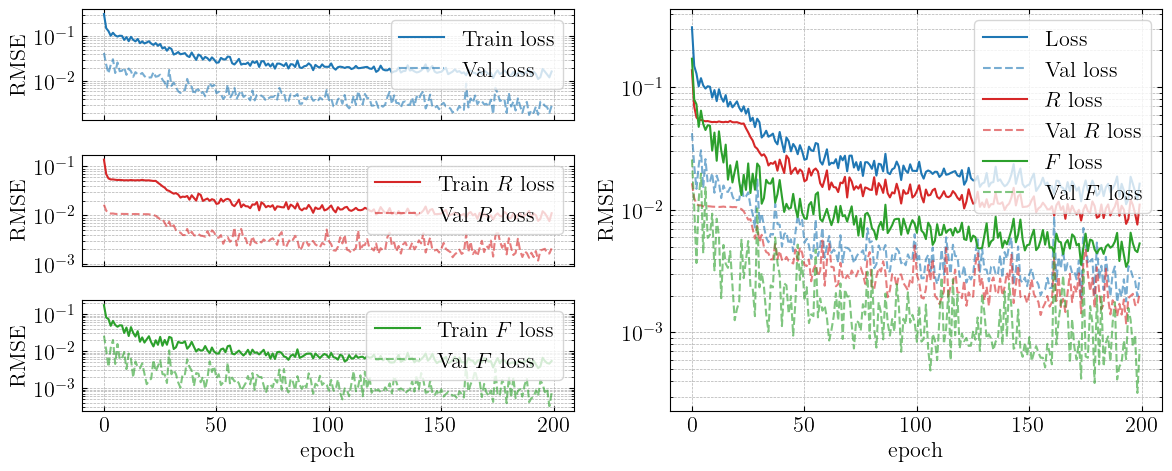

In [28]:
plot_history(history, save=SAVEPLOTS, model_name=MODEL_NAME)

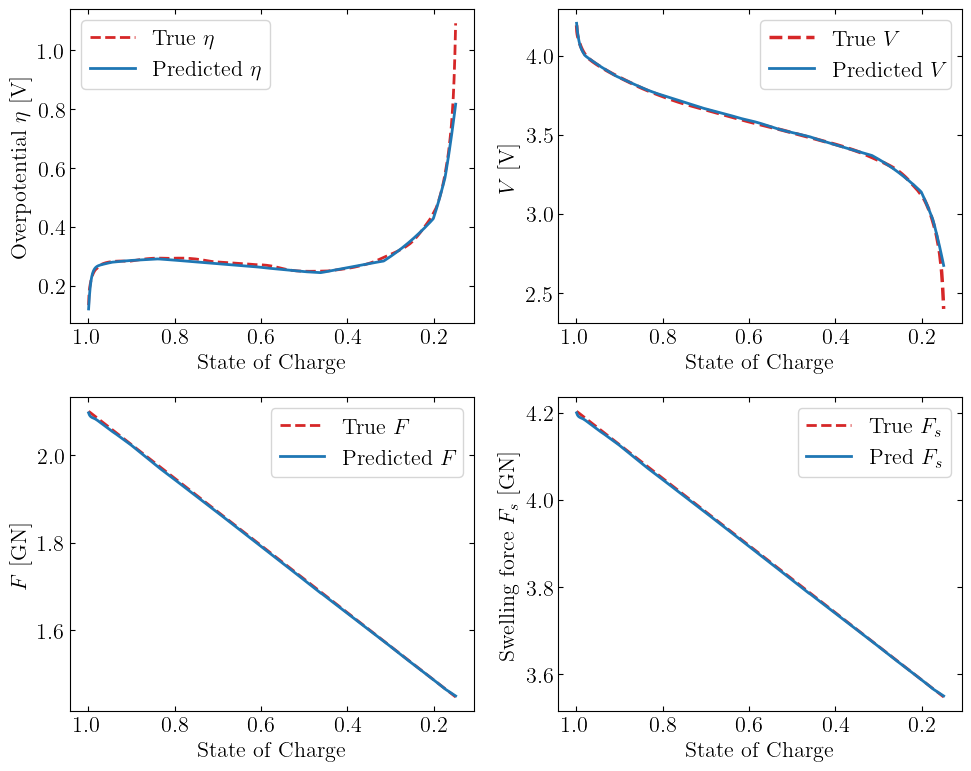

C-rate: 0.60 Ah


In [62]:

tr = 2
plot_predictions(traj_eval=tr, d_type='test_val', model=model,save = SAVEPLOTS, mode = MODE, t=False)
traj = tr
print(f'C-rate: {data["C"][data["trajectory"] == traj].values[0]:.2f} Ah')

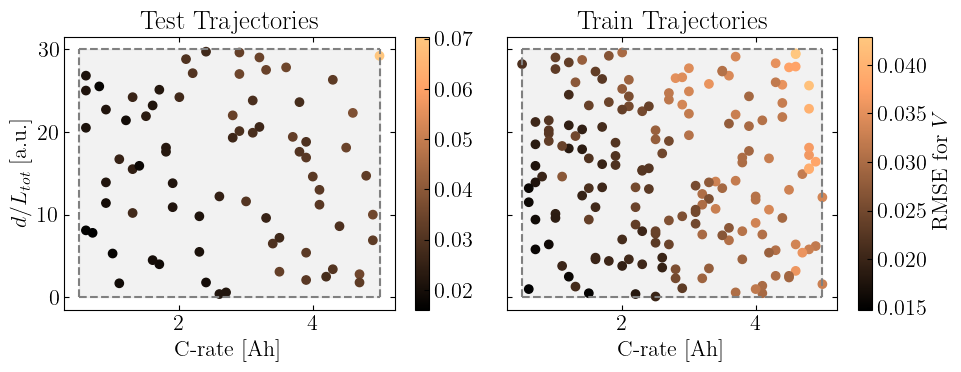

In [35]:
input_error_plot(model,save = SAVEPLOTS)

100%|██████████| 11/11 [00:44<00:00,  4.06s/it]


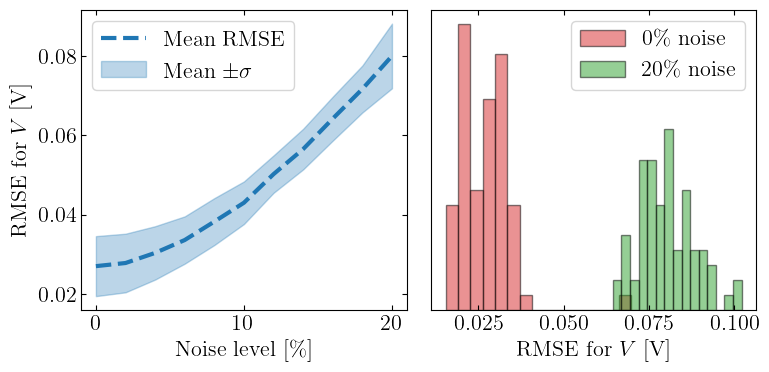

In [94]:
import_reload()
noise_plot(model,d_type = 'test_val',save = SAVEPLOTS, save_data=True)

In [91]:
import_reload() 
protocol.exp_log(model, history, name = MODEL_NAME)  